In [1]:
# My dataset is available in Google Drive, so I am accessing my Drive from Colab
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Define paths to the Muffin vs Chihuahua dataset
train_dir = '/content/drive/MyDrive/muffin vs chihuahua/train'
test_dir = '/content/drive/MyDrive/muffin vs chihuahua/test'

Mounted at /content/drive


In [2]:
import os

print(os.listdir(train_dir))
print(os.listdir(test_dir))

['muffin', 'chihuahua']
['muffin', 'chihuahua']


In [3]:
import os

print("Training Chihuahua Images:",
      len(os.listdir(os.path.join(train_dir, 'chihuahua'))))

print("Training Muffin Images:",
      len(os.listdir(os.path.join(train_dir, 'muffin'))))

print("Testing Chihuahua Images:",
      len(os.listdir(os.path.join(test_dir, 'chihuahua'))))

print("Testing Muffin Images:",
      len(os.listdir(os.path.join(test_dir, 'muffin'))))

Training Chihuahua Images: 2559
Training Muffin Images: 2174
Testing Chihuahua Images: 640
Testing Muffin Images: 544


In [4]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create ImageDataGenerator for training set
train_datagen = ImageDataGenerator(
    rescale=1./255,      # Normalize pixel values
    validation_split=0.2
)

# Training data
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

# Validation data
validation_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 3788 images belonging to 2 classes.
Found 945 images belonging to 2 classes.


In [5]:
print(train_data.class_indices)

{'chihuahua': 0, 'muffin': 1}


In [6]:
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Dropout

In [7]:
# Create CNN model for Muffin vs Chihuahua classification

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid',
                 activation='relu', input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid',
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid',
                 activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dense(64, activation='relu'))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 115200)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    14,745,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,847,297 (56.64 MB)

 Trainable params: 14,847,297 (56.64 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
from keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [10]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=validation_data
)

Epoch 1/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 703s 6s/step - accuracy: 0.7020 - loss: 0.6025 - val_accuracy: 0.8000 - val_loss: 0.4314
Epoch 2/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 576s 5s/step - accuracy: 0.8260 - loss: 0.3919 - val_accuracy: 0.6847 - val_loss: 0.6595
Epoch 3/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 586s 5s/step - accuracy: 0.8709 - loss: 0.3061 - val_accuracy: 0.8847 - val_loss: 0.2766
Epoch 4/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 587s 5s/step - accuracy: 0.9089 - loss: 0.2171 - val_accuracy: 0.8698 - val_loss: 0.3056
Epoch 5/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 582s 5s/step - accuracy: 0.9451 - loss: 0.1394 - val_accuracy: 0.8328 - val_loss: 0.5655
Epoch 6/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 616s 5s/step - accuracy: 0.9752 - loss: 0.0757 - val_accuracy: 0.8741 - val_loss: 0.4523
Epoch 7/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 629s 5s/step - accuracy: 0.9802 - loss: 0.0590 - val_accuracy: 0.8656 - val_loss: 0.5115
Epoch 8/20
119/119 ━━━━━━━━━━━━━━━━━━━━ 630s 5s/step - accuracy: 0.9892 - loss: 0.0364 - val_accu

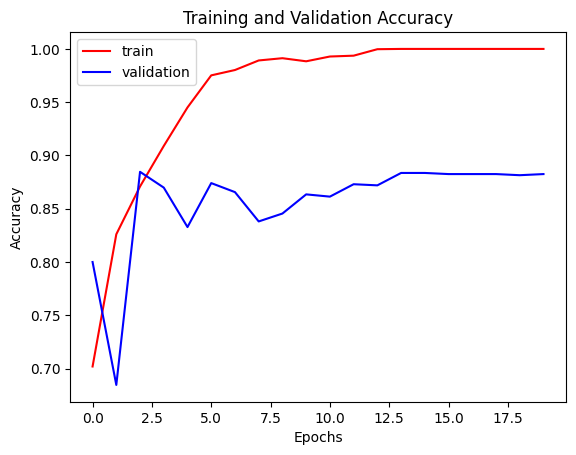

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

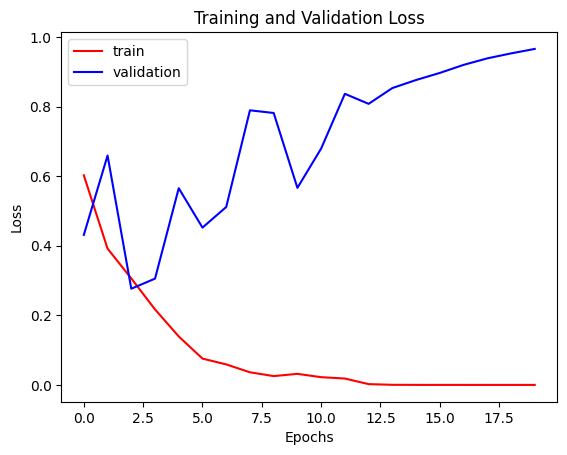

In [ ]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 1184 images belonging to 2 classes.


In [ ]:
predictions = model.predict(test_data)

37/37 ━━━━━━━━━━━━━━━━━━━━ 195s 5s/step


In [ ]:
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)

In [ ]:
true_labels = test_data.classes

In [ ]:
print(test_data.class_indices)

{'chihuahua': 0, 'muffin': 1}


In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix:")
print(cm)

print("Classification Report:")
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=list(test_data.class_indices.keys())
))

Confusion Matrix:
[[555  85]
 [ 71 473]]
Classification Report:
              precision    recall  f1-score   support

   chihuahua       0.89      0.87      0.88       640
      muffin       0.85      0.87      0.86       544

    accuracy                           0.87      1184
   macro avg       0.87      0.87      0.87      1184
weighted avg       0.87      0.87      0.87      1184



In [19]:
Improved CNN Model to Reduce Overfitting:

SyntaxError: invalid syntax (3853141542.py, line 1)

In [20]:
from keras.layers import BatchNormalization, Dropout

In [21]:
# Improved CNN model to reduce overfitting

model = Sequential()

model.add(Conv2D(32, kernel_size=(3,3), padding='valid',
                 activation='relu', input_shape=(256,256,3)))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(64, kernel_size=(3,3), padding='valid',
                 activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Conv2D(128, kernel_size=(3,3), padding='valid',
                 activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2,2), strides=2, padding='valid'))

model.add(Flatten())

model.add(Dense(128, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))
model.add(Dropout(0.3))

# Output layer for binary classification
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
compile again

In [22]:
from keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [23]:
history = model.fit(
    train_data,
    epochs=20,
    validation_data=validation_data
)

Epoch 1/20
 18/119 ━━━━━━━━━━━━━━━━━━━━ 12:10 7s/step - accuracy: 0.6456 - loss: 6.4134

KeyboardInterrupt: 

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], color='red', label='train')
plt.plot(history.history['val_accuracy'], color='blue', label='validation')
plt.title('Improved CNN Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
plt.plot(history.history['loss'], color='red', label='train')
plt.plot(history.history['val_loss'], color='blue', label='validation')
plt.title('Improved CNN Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
test_datagen = ImageDataGenerator(rescale=1./255)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

In [ ]:
predictions = model.predict(test_data)

In [ ]:
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)
true_labels = test_data.classes

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(true_labels, predicted_labels)

print("Confusion Matrix after applying Batch Normalization and Dropout:")
print(cm)

print("Classification Report after applying Batch Normalization and Dropout:")
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=list(test_data.class_indices.keys())
))

In [ ]:
Chihuahua vs Muffin

In [ ]:
import tensorflow as tf
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense, Flatten, Dropout

In [ ]:
resnet_model = Sequential()

pretrained_model = tf.keras.applications.ResNet50(
    include_top=False,
    input_shape=(256,256,3),
    pooling='max',
    weights='imagenet'
)

In [ ]:
for layer in pretrained_model.layers:
    layer.trainable = False

In [ ]:
resnet_model.add(pretrained_model)
resnet_model.add(Flatten())
resnet_model.add(Dense(512, activation='relu'))
resnet_model.add(Dropout(0.3))

# Output layer for binary classification
resnet_model.add(Dense(1, activation='sigmoid'))

In [ ]:
Dense(2, activation='sigmoid')

In [ ]:
Dense(1, activation='sigmoid')

In [ ]:
resnet_model.summary()

In [ ]:
from keras.optimizers import Adam

resnet_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history_resnet = resnet_model.fit(
    train_data,
    epochs=20,
    validation_data=validation_data
)

In [ ]:
history_resnet

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history_resnet.history['accuracy'], color='red', label='train')
plt.plot(history_resnet.history['val_accuracy'], color='blue', label='validation')
plt.title('ResNet50 Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
plt.plot(history_resnet.history['loss'], color='red', label='train')
plt.plot(history_resnet.history['val_loss'], color='blue', label='validation')
plt.title('ResNet50 Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [ ]:
predictions = resnet_model.predict(test_data)

In [ ]:
predicted_labels = (predictions > 0.5).astype(int).reshape(-1)
true_labels = test_data.classes

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(true_labels, predicted_labels)

print("ResNet50 Confusion Matrix:")
print(cm)

print("ResNet50 Classification Report:")
print(classification_report(
    true_labels,
    predicted_labels,
    target_names=list(test_data.class_indices.keys())
))